In [1]:
### imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
### read_csv
data = pd.read_csv('./disney_plus.csv')
### just grab the actual Movies 
movies_df = data[data['type'] == 'Movie'].copy()

In [3]:
# 1___Create a dataframe titled movie_ratings that contains the ratings (G, PG, TV-G, etc) and how many of those movies exist in the dataframe.
movie_ratings_df = movies_df['rating'].value_counts().reset_index()
movie_ratings_df.columns = ['rating', 'movie_counts']
movie_ratings_df

,rating,movie_counts
0,G,235
1,PG,226
2,TV-G,224
3,TV-PG,165
4,PG-13,60
5,TV-14,36
6,TV-Y7,36
7,TV-Y7-FV,6
8,TV-Y,2


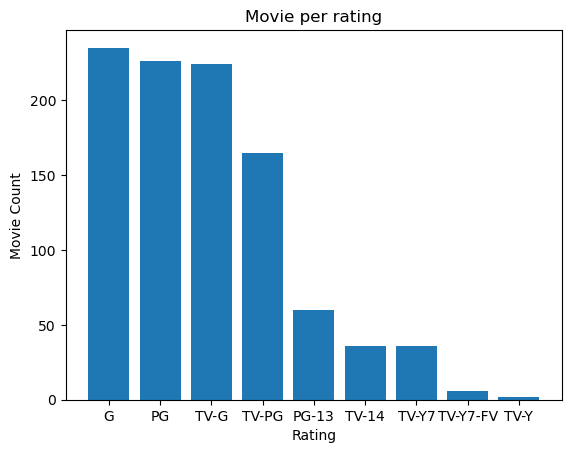

In [4]:
# 2___Using the movie_ratings dataframe, create a bar chart that displays the count of the top 5 movie ratings.
plt.bar(movie_ratings_df['rating'], movie_ratings_df['movie_counts'])
plt.title('Movie per rating')
plt.xlabel('Rating')
plt.ylabel('Movie Count')
plt.show()

In [5]:
# 3___Using movies_df, subset the data to create a new dataframe named year_duration
year_duration = movies_df.copy()
year_duration = year_duration[['release_year','duration']]
year_duration['duration'] = year_duration['duration'].str.strip(' min').astype(int)
year_duration

,release_year,duration
0,2021,88
1,2011,93
2,2014,127
6,2009,106
7,2021,22
...,...,...
1359,2001,73
1361,1978,104
1362,1986,75
1363,1963,80


In [21]:
# 4___Using your year_duration dataframe, filter for movies released between 1975 and 1984 (inclusive) and find the:

# Minimum duration
# Maximum duration
# Average duration
year_duration[(year_duration['release_year'] >= 1975) & (year_duration['release_year'] <= 1984)]['duration'].agg(['min', 'max', 'mean'])

min       2.000000
max     135.000000
mean     85.914286
Name: duration, dtype: float64

In [20]:
### This is for all years
print(f"Min: {year_duration['duration'].min()} mins")
print(f"Max: {year_duration['duration'].max()} mins")
print(f"Avg: {year_duration['duration'].mean().astype(int)} mins")

Min: 2 mins
Max: 183 mins
Avg: 73 mins


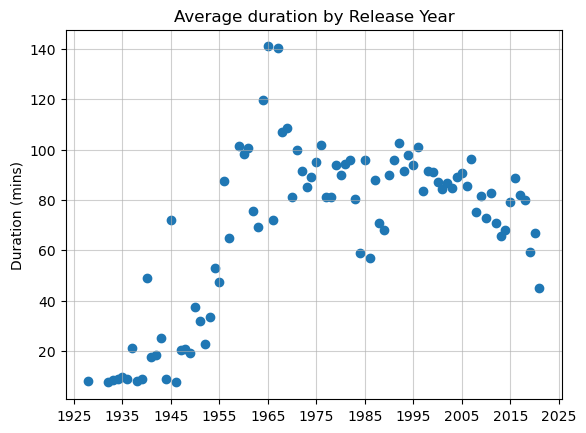

In [7]:
# 5___Using the year_duration dataframe, create a scatterplot that shows movie durations over the years. Add a descriptive title to your chart.
# After creating your plot, answer the following in a comment or markdown cell:
# Do you notice any correlation between release year and movie duration?
year_duration_avg_df = year_duration.groupby('release_year')['duration'].mean().round(2).reset_index(name='avg_duration_mins')

plt.scatter(year_duration_avg_df['release_year'],year_duration_avg_df['avg_duration_mins'])
### i usually don't like the default tick choices
plt.xticks(range(1925,2030,10))
plt.ylabel('Duration (mins)')
plt.title('Average duration by Release Year')
### bit easier to read
plt.grid(alpha=0.6)
plt.show()

Looks like short films start us off up until ~1940
then inevitably, people start experimenting and films get longer.
So long it seems, that they decided to pull it back a bit around 1970.
From 1970 on its steady around 90mins with a slight downward
trend starting in 2000. 
## ---- Thought this was interesting ----
### In 2004 the US Senate passed a resolution recognizing the first National ADHD Awareness Day. Which later grew into a full awareness month in October.
##### Maybe the industry caters to this now? That's about where the downtrend starts, atleast in this dataset...

In [8]:
# 6___Find the actual correlation value between release_year and duration.
# 💡 Hint: Use .corr() on the year_duration dataframe.
# Answer the following in a comment or markdown cell:
# Based on the correlation value, is there a meaningful correlation between release year and duration?
print(year_duration_avg_df.corr())

                   release_year  avg_duration_mins
release_year           1.000000           0.588257
avg_duration_mins      0.588257           1.000000


## 0.588 is a slight positive trend.
### It does seem from our dataset that as time passes, movie length has increased. If the timeframe is tightened to the last 30 years though, we could be at the start of something new. There's a significant plateau later that the early years may be skewing.

In [9]:
# 7___Using movies_df, find which year had the most G-rated movie releases.
# 🎯 Challenge: Can you accomplish this in a single line of code?
movies_df[movies_df['rating'] == 'G']['release_year'].value_counts().head(1)

release_year
2003    12
Name: count, dtype: int64

In [10]:
# 8___Find which year had the most total movie releases.
# Create a new dataframe containing only movies from that year.
# Convert the duration column to integers.
# Use the IQR method to determine the upper and lower cutoffs for outliers.
# Calculate what percentage of movies from that year had durations that were statistical outliers.
# 💡 Hint: Outlier cutoffs are defined as:

# Lower cutoff: Q1 − (1.5 × IQR)
# Upper cutoff: Q3 + (1.5 × IQR)
movies_df['release_year'].value_counts().head(1)

release_year
2020    72
Name: count, dtype: int64

In [11]:
### only movies from 2020 and convert duration to int
movies_2020_df = movies_df[movies_df['release_year'] == 2020].copy().reset_index()
movies_2020_df['duration'] = movies_2020_df['duration'].str.strip(' min').astype(int)
movies_2020_df['duration'].sort_values()

30      3
60      5
16      6
71      6
69      7
     ... 
36    122
25    123
54    160
18    180
20    182
Name: duration, Length: 72, dtype: int64

In [12]:
### IQR = Interquartile Range... needs 1st and 3rd quartiles for cutoff math
Q1 = movies_2020_df['duration'].quantile(0.25)
Q3 = movies_2020_df['duration'].quantile(0.75)

### subtract the two for IQR
IQR = Q3 - Q1

### now the provided math 
## i was getting negative duration times and that'll never work... so max()
lower = max(0, Q1 - (1.5*IQR))
upper = Q3 + (1.5*IQR)

### (outliers / total_movies_in_2020) * 100 for %
outliers_pct = (movies_2020_df[movies_2020_df['duration'] > upper].shape[0] / movies_2020_df.shape[0]) * 100

### output that joint
print(f"upper cutoff: {upper} mins")
print(f"lower cutoff: {lower} mins")
print(f"outliers: {round(outliers_pct, 2)}%")

upper cutoff: 171.5 mins
lower cutoff: 0 mins
outliers: 2.78%


In [13]:
# 9___Add a new column called length_category to movies_df that 
# categorizes each movie as one of the following:
# Category	Duration
# short	30 minutes or less
# average	Between 31–120 minutes
# long	More than 120 minutes
# Bonus: Once the column is created, create a pie chart showing the distribution of 
# movie length categories.

### don't mess with orig data
movies_category_df = movies_df.copy()

### returns str based on movie duration
def cat_len(dur):
    if dur <= 30:
        return 'short'
    elif dur <= 120:
        return 'average'
    else:
        return 'long'

### make duration int 
movies_category_df['duration'] = movies_category_df['duration'].str.strip(' min').astype(int)
### .apply our func as no other could
movies_category_df['length_category'] = movies_category_df['duration'].apply(cat_len)

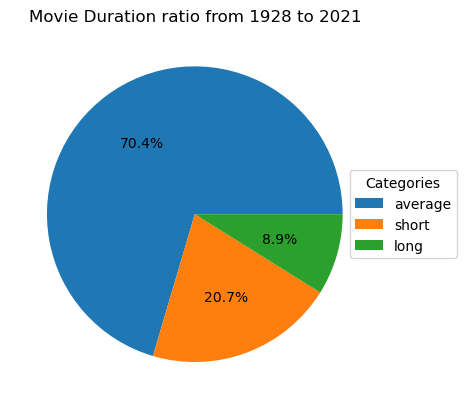

In [14]:
### make a pie chart showing ratio of duration categories
cat_pie_df = movies_category_df['length_category'].value_counts().reset_index()
cat_pie_df.columns = ['Category', 'Count']

### grab a list of the categories
cats = cat_pie_df['Category'].unique()

### explode the pie to access wedges for the legend
wedges, text, autotexts = plt.pie(cat_pie_df['Count'], autopct='%1.1f%%')

plt.title('Movie Duration ratio from 1928 to 2021')
plt.legend(wedges, cats,
          title="Categories",
          loc="center left",
          bbox_to_anchor=(0.9, 0, 1, 1))
plt.show()

In [15]:
# 10___Create a new column called gap that calculates the difference between the year a movie was added to Disney+ 
# and its original release_year.
# Find the movie with the greatest gap.
# Find the average gap across all movies.

### dont hurt orig df
gap_movies_df = movies_df.copy()
### extract year from date_added -> 'year_added' 
gap_movies_df['year_added'] = pd.to_datetime(gap_movies_df['date_added']).dt.year
### do the subtraction thing into new 'gap' column
gap_movies_df['gap'] = (gap_movies_df['year_added'] - gap_movies_df['release_year'])

In [16]:
### get the index from the max() gap 
max_gap_index = gap_movies_df.index[gap_movies_df['gap'] == gap_movies_df['gap'].max()]
### access the row from the gap.max() index
gap_movies_df.loc[max_gap_index]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,gap
1146,s1147,Movie,Steamboat Willie,"Walt Disney, Ub Iwerks",Walt Disney,United States,"November 12, 2019",1928,TV-Y7,8 min,"Animation, Family, Kids",Watch Mickey Mouse's classic cartoon debut. Se...,2019,91


In [17]:
### calculate the numbers 
gap_average = gap_movies_df['gap'].mean()
print(f"Average years between release date and Disney+ addition: {round(gap_average,1)} years")

Average years between release date and Disney+ addition: 21.2 years


In [18]:
### or just look at em.... would ya look at em... just look at em... psshh
gap_movies_df['gap'].describe()

count    991.000000
mean      21.181635
std       23.907129
min        0.000000
25%        3.000000
50%       13.000000
75%       27.000000
max       91.000000
Name: gap, dtype: float64